In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [2]:
url = "https://raw.githubusercontent.com/Yashappin/Machine-Learning/master/TvMarketing.csv"
df = pd.read_csv(url)

print(df.head())

      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


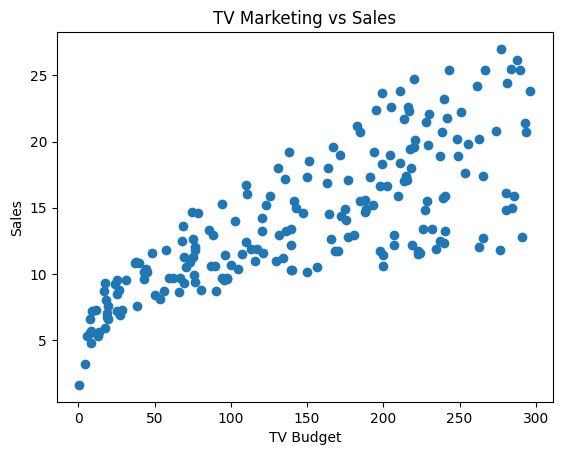

In [3]:
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("TV Marketing vs Sales")
plt.show()

In [4]:
X = df[["TV"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (160, 1)
Testing shape: (40, 1)


In [5]:
model = LinearRegression()

model.fit(X_train,y_train)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 7.119638430592953
Coefficient: [0.04652973]


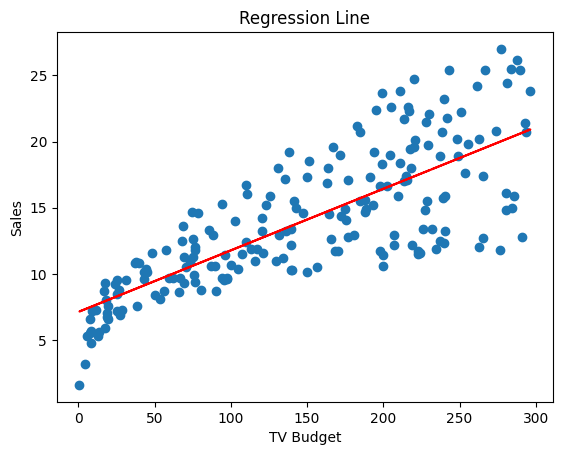

In [6]:
plt.scatter(X,y)

plt.plot(X,model.predict(X),color="red")

plt.xlabel("TV Budget")
plt.ylabel("Sales")

plt.title("Regression Line")

plt.show()

In [7]:
y_pred = model.predict(X_test)

results = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})

print(results.head())

     Actual  Predicted
95     16.9  14.717944
15     22.4  16.211548
30     21.4  20.748197
158     7.3   7.664036
128    24.7  17.370139


In [8]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("RMSE:",rmse)
print("R2 Score:",r2)

RMSE: 3.194472431998898
R2 Score: 0.6766954295627076


In [9]:
url = "https://raw.githubusercontent.com/KeithGalli/machine-learning/master/data/FuelConsumption.csv"
df = pd.read_csv(url)

df = df[["ENGINESIZ","VEHICLECLASS","CO2EMISSIONS"]]
print(df.head())

HTTPError: HTTP Error 404: Not Found

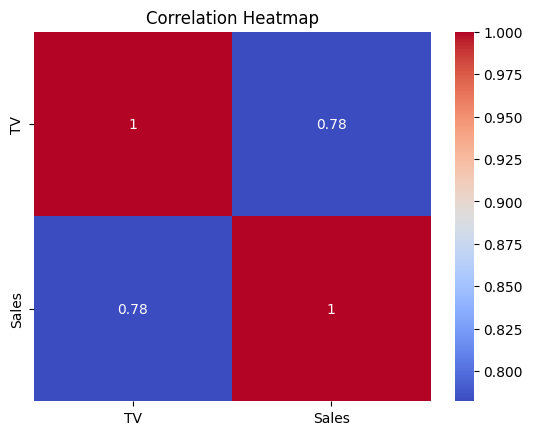

In [10]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [14]:
print(df.head())

      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


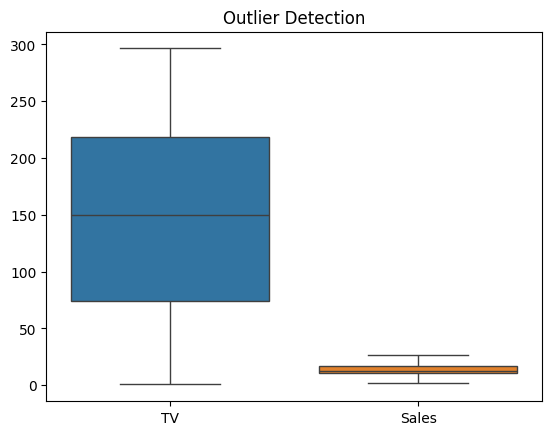

In [15]:
sns.boxplot(data=df.select_dtypes(include=['number']))

plt.title("Outlier Detection")

plt.show()

In [17]:
print(df.columns)

Index(['TV', 'Sales'], dtype='str')


In [19]:
numeric_df = df.select_dtypes(include='number')

print(numeric_df.head())

      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


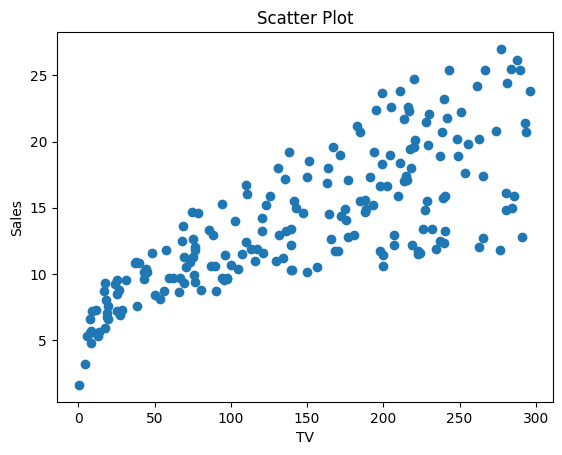

In [20]:
plt.scatter(numeric_df.iloc[:,0], numeric_df.iloc[:,1])

plt.xlabel(numeric_df.columns[0])
plt.ylabel(numeric_df.columns[1])

plt.title("Scatter Plot")

plt.show()

In [21]:
X = numeric_df.iloc[:,0:1]
y = numeric_df.iloc[:,1]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)

In [25]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 2.444420003751042
MSE: 10.204654118800956
RMSE: 3.194472431998898


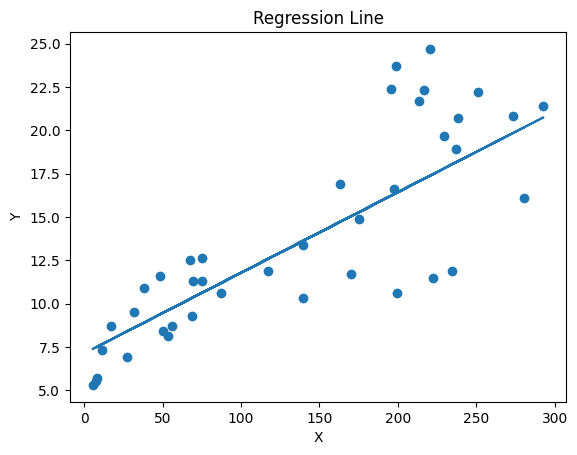

In [26]:
plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Regression Line")

plt.show()